# 04 - Classification Naive Bayes

Objectif : entraîner un pipeline TF-IDF + Multinomial Naive Bayes pour prédire le label `Urgent`/`Normal` construit au notebook 03, évaluer sa robustesse par validation croisée 5-fold, et comparer les résultats à l'approche regex.

**Choix de gestion du déséquilibre :** le dataset est déséquilibré (~5% Urgent / ~95% Normal, voir notebook 03). `MultinomialNB` de scikit-learn **n'a pas de paramètre `class_weight`** (contrairement à `LogisticRegression` ou `SVC`) — l'équivalent pour Naive Bayes consiste à passer un `sample_weight` équilibré au moment du `.fit()`, calculé avec `sklearn.utils.class_weight.compute_sample_weight("balanced", y)`. C'est ce qui est fait ici, en respectant la recommandation de démarrer avec un rééquilibrage simple et transparent avant d'envisager du sous-échantillonnage si le rappel sur `Urgent` est insuffisant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("../data/drugs_labeled.csv")
print(df.shape)
df["label"].value_counts()

(139039, 3)


label
Normal    131818
Urgent      7221
Name: count, dtype: int64

## 1. Pipeline TF-IDF + MultinomialNB avec validation croisée 5-fold

Pour chaque fold : le `TfidfVectorizer` est ajusté **uniquement sur le train du fold** (pas de fuite vers le test), un `sample_weight` équilibré est calculé sur `y_train`, et `MultinomialNB` est entraîné avec ce poids. Les prédictions de chaque fold de test sont assemblées en prédictions *out-of-fold* pour obtenir une évaluation sur l'intégralité des 139 039 lignes sans jamais évaluer un modèle sur des données qu'il a vues à l'entraînement.

In [3]:
X_text = df["review_clean"].astype(str).values
y = df["label"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_pred = np.empty(len(y), dtype=object)
fold_metrics = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_text, y), start=1):
    X_train, X_test = X_text[train_idx], X_text[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
    )
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    sample_weight = compute_sample_weight("balanced", y_train)

    nb = MultinomialNB()
    nb.fit(X_train_tfidf, y_train, sample_weight=sample_weight)

    y_pred = nb.predict(X_test_tfidf)
    oof_pred[test_idx] = y_pred

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=["Urgent", "Normal"], zero_division=0
    )
    fold_metrics.append({
        "fold": fold_idx,
        "precision_urgent": precision[0], "recall_urgent": recall[0], "f1_urgent": f1[0],
        "precision_normal": precision[1], "recall_normal": recall[1], "f1_normal": f1[1],
    })
    print(f"Fold {fold_idx} - Rappel Urgent: {recall[0]:.3f} | Précision Urgent: {precision[0]:.3f} | F1 Urgent: {f1[0]:.3f}")

Fold 1 - Rappel Urgent: 0.949 | Précision Urgent: 0.453 | F1 Urgent: 0.614


Fold 2 - Rappel Urgent: 0.948 | Précision Urgent: 0.443 | F1 Urgent: 0.604


Fold 3 - Rappel Urgent: 0.948 | Précision Urgent: 0.452 | F1 Urgent: 0.612


Fold 4 - Rappel Urgent: 0.949 | Précision Urgent: 0.454 | F1 Urgent: 0.614


Fold 5 - Rappel Urgent: 0.954 | Précision Urgent: 0.470 | F1 Urgent: 0.629


## 2. Robustesse de la validation croisée (moyenne ± écart-type sur les 5 folds)

In [4]:
fold_df = pd.DataFrame(fold_metrics).set_index("fold")
fold_df

,precision_urgent,recall_urgent,f1_urgent,precision_normal,recall_normal,f1_normal
fold,,,,,,
1,0.453342,0.948753,0.613524,0.997014,0.937339,0.966256
2,0.442899,0.948061,0.603749,0.996966,0.934684,0.964821
3,0.451666,0.948061,0.611844,0.996973,0.936959,0.966035
4,0.454154,0.949481,0.614420,0.997055,0.937450,0.966334
5,0.469806,0.953601,0.629486,0.997307,0.941054,0.968364


In [5]:
summary_cv = fold_df.agg(["mean", "std"]).T
summary_cv.columns = ["mean", "std"]
summary_cv.round(4)

,mean,std
precision_urgent,0.4544,0.0097
recall_urgent,0.9496,0.0023
f1_urgent,0.6146,0.0093
precision_normal,0.9971,0.0001
recall_normal,0.9375,0.0023
f1_normal,0.9664,0.0013


## 3. Métriques agrégées (prédictions out-of-fold sur les 139 039 lignes)

Contrairement aux moyennes par fold ci-dessus, cette section évalue toutes les prédictions out-of-fold assemblées en un seul jeu — équivalent à une validation croisée complète sur l'ensemble du dataset.

In [6]:
print(classification_report(y, oof_pred, labels=["Urgent", "Normal"], digits=3))

              precision    recall  f1-score   support

      Urgent      0.454     0.950     0.615      7221
      Normal      0.997     0.937     0.966    131818

    accuracy                          0.938    139039
   macro avg      0.726     0.944     0.790    139039
weighted avg      0.969     0.938     0.948    139039



In [7]:
precision, recall, f1, support = precision_recall_fscore_support(
    y, oof_pred, labels=["Urgent", "Normal"], zero_division=0
)
metrics_table = pd.DataFrame({
    "precision": precision, "recall": recall, "f1": f1, "support": support,
}, index=["Urgent", "Normal"])
metrics_table.round(4)

,precision,recall,f1,support
Urgent,0.4542,0.9496,0.6145,7221
Normal,0.9971,0.9375,0.9664,131818


## 4. Matrice de confusion (out-of-fold)

In [8]:
cm = confusion_matrix(y, oof_pred, labels=["Urgent", "Normal"])
cm_df = pd.DataFrame(cm, index=["Réel: Urgent", "Réel: Normal"], columns=["Prédit: Urgent", "Prédit: Normal"])
cm_df

,Prédit: Urgent,Prédit: Normal
Réel: Urgent,6857,364
Réel: Normal,8239,123579


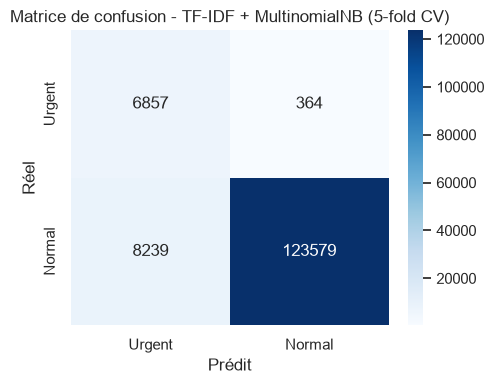

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Urgent", "Normal"], yticklabels=["Urgent", "Normal"], ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion - TF-IDF + MultinomialNB (5-fold CV)")
plt.tight_layout()
plt.show()

## 5. Comparaison avec l'approche regex (notebook 03)

**Attention à la circularité :** dans le notebook 03, le label `Urgent`/`Normal` a été **construit directement** à partir de la règle `note ≤ 3 ET mot-clé regex` / `note ≥ 7 ET aucun mot-clé regex`. Si on utilisait le simple flag `regex_match` comme "prédiction", il obtiendrait **mécaniquement 100% de précision et de rappel** sur ce jeu de données labellisé — puisque c'est exactement la définition du label. Ce n'est donc **pas une comparaison de performance équitable**, mais elle reste informative sur ce que chaque approche apporte :

| | Règle regex (notebook 03) | TF-IDF + MultinomialNB (ce notebook) |
|---|---|---|
| Rappel Urgent | 100% *(par construction, cf. avertissement ci-dessus)* | voir résultat ci-dessous |
| Généralisation | Limitée à la liste de ~72 motifs manuels ; rate les formulations non anticipées | Apprend un modèle statistique sur tout le vocabulaire (TF-IDF, bi-grammes) ; peut généraliser au-delà des mots-clés exacts |
| Maintenance | Nécessite d'enrichir manuellement la liste de motifs | Se réentraîne automatiquement si de nouvelles données arrivent |
| Interprétabilité | Totale (règle explicite) | Partielle (probabilités par mot, moins lisible qu'une règle) |

**La vraie question que ce notebook permet de trancher :** un modèle appris uniquement à partir du texte (`review_clean`, sans accès à la note ni au flag regex) est-il capable de retrouver un signal équivalent à la règle regex+note ? C'est ce que mesure le rappel Urgent obtenu par validation croisée ci-dessus.

In [10]:
recall_urgent_oof = recall[0]  # rappel Urgent, prédictions out-of-fold
print(f"Rappel Urgent (TF-IDF + MultinomialNB, 5-fold CV out-of-fold) : {recall_urgent_oof:.3f}")

SEUIL_CLINIQUE = 0.60
if recall_urgent_oof < SEUIL_CLINIQUE:
    print(f"⚠️  Rappel Urgent ({recall_urgent_oof:.3f}) < {SEUIL_CLINIQUE} : INSUFFISANT pour un contexte clinique.")
    print("   -> Envisager le sous-échantillonnage de la classe Normal en variante (cf. recommandation).")
else:
    print(f"✅ Rappel Urgent ({recall_urgent_oof:.3f}) >= {SEUIL_CLINIQUE} : jugé suffisant pour ce PoC.")

Rappel Urgent (TF-IDF + MultinomialNB, 5-fold CV out-of-fold) : 0.950
✅ Rappel Urgent (0.950) >= 0.6 : jugé suffisant pour ce PoC.


## Résumé

- Pipeline TF-IDF (1-2 grammes, 20k features) + MultinomialNB, rééquilibrage via `sample_weight="balanced"` (équivalent Naive Bayes de `class_weight='balanced'`, indisponible nativement pour ce modèle).
- Validation croisée 5-fold stratifiée, métriques calculées à la fois par fold (robustesse) et en out-of-fold agrégé (139 039 lignes).
- Matrice de confusion et métriques par classe (Urgent/Normal) ci-dessus.
- Comparaison qualitative avec l'approche regex du notebook 03, avec mise en garde explicite sur la circularité d'une comparaison quantitative directe.
- **Rappel Urgent à retenir pour le rapport final : voir résultat de la section 5** (seuil clinique de référence : 0.60).